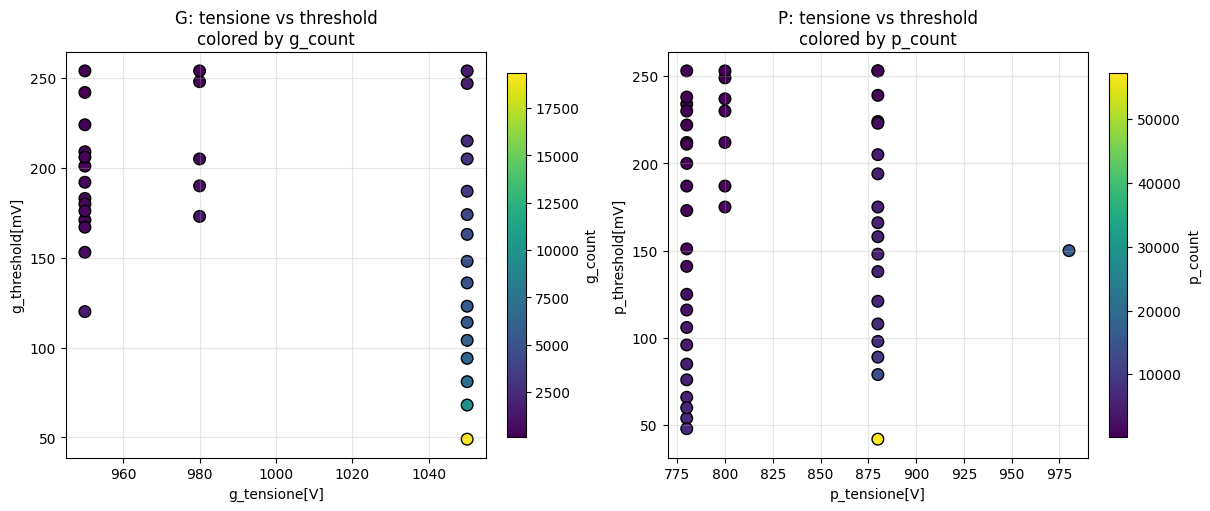

In [7]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Load data from either the notebook folder or the workspace root
for candidate in [Path("ch_4-5.csv"), Path("Data/calibration/ch_4-5.csv")]:
    if candidate.exists():
        data_path = candidate
        break
else:
    raise FileNotFoundError("Could not find 'ch_4-5.csv'.")

df = pd.read_csv(data_path)


def normalize(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


col_map = {normalize(c): c for c in df.columns}


def find_channel_col(channel: str, quantity: str):
    prefix = f"{channel}_"
    return next(
        (
            orig
            for norm, orig in col_map.items()
            if norm.startswith(prefix) and quantity in norm
        ),
        None,
    )


channel_pairs = [
    ("g", "G"),
    ("p", "P"),
]

plot_columns = []
for channel, label in channel_pairs:
    tension_col = find_channel_col(channel, "tensione")
    threshold_col = find_channel_col(channel, "threshold")
    count_col = find_channel_col(channel, "count")

    if not tension_col or not threshold_col or not count_col:
        raise ValueError(
            f"Could not find tension, threshold, and count columns for channel {label}. "
            f"Found: {list(df.columns)}"
        )

    plot_columns.append(
        (tension_col, threshold_col, count_col, f"{label}: tensione vs threshold")
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, (xcol, ycol, ccol, title) in zip(axes, plot_columns):
    sc = ax.scatter(
        df[xcol],
        df[ycol],
        c=df[ccol],
        cmap="viridis",
        s=70,
        edgecolor="k",
    )
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{title}\ncolored by {ccol}")
    ax.grid(True, alpha=0.3)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.9)
    cbar.set_label(ccol)

plt.show()